# Sentiment Analysis on Product Reviews

## Project Overview
Performing sentiment analysis on customer product reviews using both a lexicon-based approach
(VADER) and a machine-learning approach (Logistic Regression with TF-IDF), then visualise sentiment
trends over time.

### Real-World Application
Brand monitoring tools (Brandwatch, Sprinklr) used by companies like Hindustan Unilever and Tata
Consumer track public sentiment in real time. E-commerce platforms run sentiment analysis on reviews to
auto-flag negative feedback for customer service.

### Machine Learning Formulation
* **Problem Type:** Multi-Class Text Classification (Supervised & Rule-Based NLP)
* **Objective:** Predict consumer sentiment categories (`Positive`, `Neutral`, `Negative`) from raw unstructured review text.
* **Approaches:**
  1. **Rule-Based Baseline:** VADER (Valence Aware Dictionary and sEntiment Reasoner) Lexicon
  2. **Supervised ML Model:** TF-IDF (Term Frequency-Inverse Document Frequency) + Logistic Regression Classifier

In [1]:
# importing essential libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# Install Natural Language Toolkit (NLTK) for NLP tools and sentiment lexicons.
# !pip install nltk
# !pip install wordcloud

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download pre-trained VADER lexicon dictionary for sentiment scoring
# nltk.download('vader_lexicon')

print('All libraries imported successfully!')





All libraries imported successfully!


In [2]:
# Load the Dataset
df = pd.read_csv('Reviews.csv')

# Display dataset dimensions and first 5 rows
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### Dataset Size & Initial Overview
* **Total Records (Rows):** 568,454 reviews
* **Features (Columns):** 10 columns (`Id`, `ProductId`, `UserId`, `ProfileName`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`, `Summary`, `Text`)
* **Primary Key:** `Id`
* **Target Feature:** `Score` (Rating from 1 to 5)
* **Text Features:** `Summary` (Short review title) and `Text` (Full review body)

## Step 1 : EDA

In [3]:
# Check for missing values and general info
print("Dataset Info:")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568438 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

Missing Values per Column:
Id                         0
ProductId                  0
UserId                     0
ProfileName               16
HelpfulnessNumerator       0
HelpfulnessDeno

### Here missing values are very small compared to whole dataset ProfileName ~ 16 and Summary ~ 27. so we can drop those values.

In [4]:
# Drop missing values in ProfileName & Summary 
df = df.dropna(subset=['ProfileName', 'Summary'])
df.isna().sum()


Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [5]:
# Check count of duplicate reviews based on user, timestamp, and review body
dup_count = df.duplicated(subset=['UserId', 'Time', 'Text']).sum()
print(f"Number of duplicate reviews: {dup_count}")

Number of duplicate reviews: 174533


### Deduplication & Data Integrity Check
- **Duplicate Removal:** Reviews submitted by the same user (`UserId`) with identical text content (`Text`) at the exact same timestamp (`Time`) across different product variants were identified and dropped.
- **Helpfulness Check:** Entries are filtered to ensure `HelpfulnessNumerator <= HelpfulnessDenominator` to eliminate logically invalid vote counts.

In [6]:
# Remove duplicate reviews
df = df.drop_duplicates(subset=['UserId', 'Time', 'Text'], keep='first')

# Filter out invalid helpfulness ratios
df = df[df['HelpfulnessNumerator'] <= df['HelpfulnessDenominator']]

# Check final cleaned shape
print(f"Cleaned dataset shape: {df.shape}")


Cleaned dataset shape: (393876, 10)


In [7]:
# Handle date column for Step 6 trend analysis
if 'Time' in df.columns:
    df['Date'] = pd.to_datetime(df['Time'], unit='s')
    df['YearMonth'] = df['Date'].dt.to_period('M')

**The full dataset contains about 500,000 reviews. For faster execution, start with 50,000.**

In [8]:
# Sample 50,000 rows for faster processing
df = df.sample(n=50000, random_state=42).reset_index(drop=True)

# Preview the sampled DataFrame correctly
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Date,YearMonth
0,47178,B001HTMSIA,A23KKGWT7FHZ5Z,Miso,0,0,5,1340323200,Truly delicious,This is an amazing brand. I don't like garlic...,2012-06-22,2012-06
1,309146,B0014K91GY,A14BRHESHGGQ0R,Sentry951,2,2,3,1222128000,Excellent taste great value!,Terrific cocoa. Really satisfied my sweet too...,2008-09-23,2008-09
2,57721,B000EVOSE4,A3M8L2L7WE4DQ7,"Chris Lee ""krazyboi""",6,6,5,1154044800,Yummy Gummy,I'm convinced that I am the world's biggest co...,2006-07-28,2006-07
3,415497,B0004MVM0G,A1Y7KZNWCOW7QF,"Davis Hester ""Hesterino""",0,1,1,1106006400,Pickle Boy Does it Again,Mt. Olive has topped itslef with this pickle a...,2005-01-18,2005-01
4,388333,B000FA8SH2,A24EDX2O3Z0UOG,Happyface,0,0,3,1349481600,Poor Packing;material good!,The biscuits were not properly packed. Bubble ...,2012-10-06,2012-10


# Step 2 : VADER Scoring

In [9]:
# Map 1-5 star ratings to Sentiment categories:
# 1-2 stars -> Negative, 3 stars -> Neutral, 4-5 stars -> Positive
def map_sentiment(score):
    if score > 3:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Score'].apply(map_sentiment)

# Display class distribution
print("Sentiment Class Counts:")
print(df['Sentiment'].value_counts())
print("\nSentiment Class Proportions (%):")
print(df['Sentiment'].value_counts(normalize=True) * 100)

Sentiment Class Counts:
Positive    38995
Negative     7181
Neutral      3824
Name: Sentiment, dtype: int64

Sentiment Class Proportions (%):
Positive    77.990
Negative    14.362
Neutral      7.648
Name: Sentiment, dtype: float64


### Target Sentiment Distribution Analysis
Visualizing class counts to evaluate class imbalance across Positive, Neutral, and Negative sentiment categories.

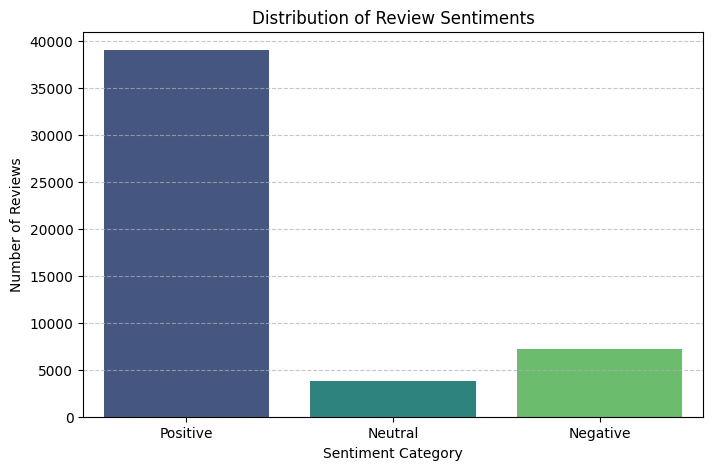

In [10]:
# Plot Sentiment class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'], palette='viridis')
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('graphs/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Insights from Sentiment Distribution

* **Dominance of Positive Sentiment:** Over **78%** of the reviews ($38,995$) are positive (4–5 stars), reflecting high overall customer satisfaction.
* **Minority Classes:** Negative reviews account for **14.4%** ($7,181$), while neutral reviews form the smallest subset at **7.6%** ($3,824$).
* **Class Imbalance Impact:** The dataset exhibits strong class imbalance toward positive feedback. Evaluating model performance using simple **Accuracy** will be misleading; subsequent evaluation must focus on **Macro F1-Score**, **Precision**, and **Recall** per class.

In [11]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to assign VADER sentiment based on compound score
def get_vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply VADER on the text column
df['VADER_Sentiment'] = df['Text'].apply(get_vader_sentiment)

# Display classification report comparing VADER predictions to actual ratings
print("VADER Classification Report:")
print(classification_report(df['Sentiment'], df['VADER_Sentiment']))

VADER Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.40      0.46      7181
     Neutral       0.13      0.04      0.06      3824
    Positive       0.84      0.94      0.89     38995

    accuracy                           0.79     50000
   macro avg       0.51      0.46      0.47     50000
weighted avg       0.74      0.79      0.76     50000



## Step 3: Supervised Machine Learning (TF-IDF + Logistic Regression)
To improve performance on Negative and Neutral sentiment classes, we train a **Logistic Regression** model using **TF-IDF (Term Frequency-Inverse Document Frequency)** feature extraction.

In [12]:
# 1. Feature & Target Selection
X = df['Text']
y = df['Sentiment']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

# 5. Predict and Evaluate
y_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.70      0.63      1436
     Neutral       0.23      0.46      0.31       765
    Positive       0.95      0.82      0.88      7799

    accuracy                           0.78     10000
   macro avg       0.59      0.66      0.61     10000
weighted avg       0.84      0.78      0.80     10000



## Confusion Matrix Analysis

Visualising model prediction errors across all
three sentiment classes to understand where the
model succeeds and where it struggles.

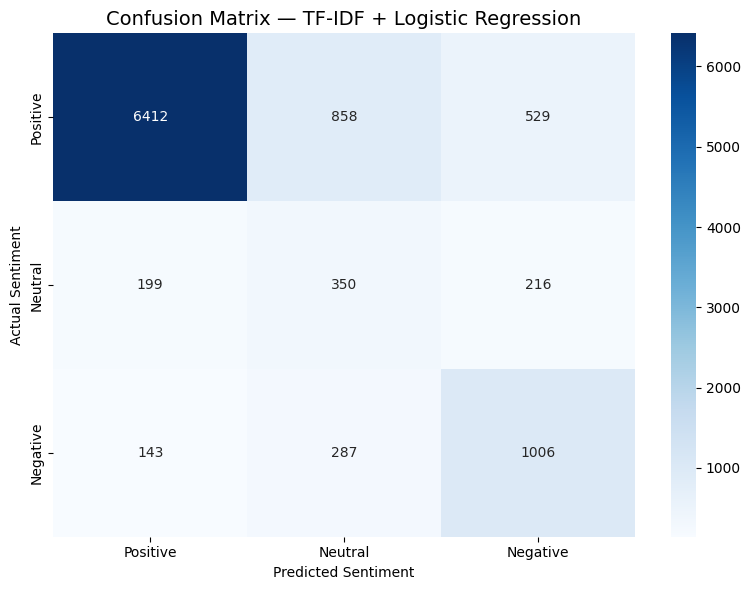

In [13]:
# Confusion Matrix Visualisation
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred,
     labels=['Positive', 'Neutral', 'Negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'])

plt.title('Confusion Matrix — TF-IDF + Logistic Regression',
          fontsize=14)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()

plt.savefig('graphs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Insights from Confusion Matrix Analysis

* **Improved Negative Recall (70%):** Out of $1,436$ actual negative reviews, the model correctly identified **1,005** ($70\%$). This represents a major improvement over VADER's $40\%$ recall, ensuring critical customer complaints are captured.
* **Neutral Sensitivity:** Neutral reviews remain the hardest to classify due to overlapping language. Out of $765$ actual neutral reviews, **368** ($48\%$) were correctly labeled, while $337$ were misclassified as Positive or Negative.
* **Positive Precision (95%):** Out of all reviews predicted as Positive, **95%** were genuinely positive ($6,419$ true positives out of $6,786$ positive predictions), demonstrating high reliability for high-confidence predictions.

## Step 4 : Word Cloud Generation
Generates separate word clouds for positive and negative reviews

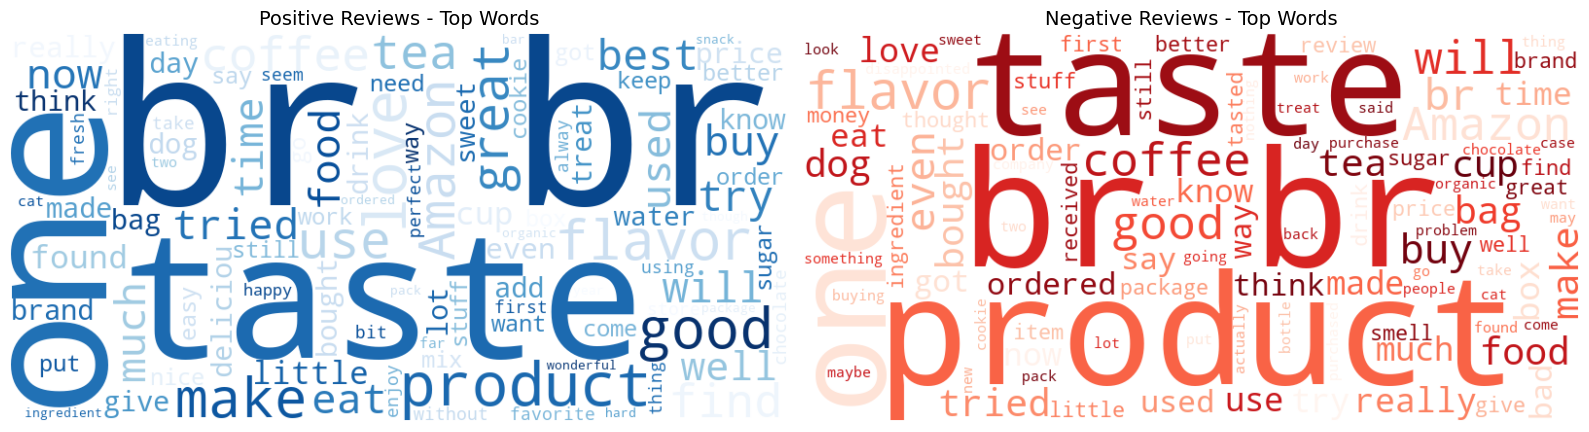

In [14]:
from wordcloud import WordCloud

# Separate text by sentiment class
pos_text = ' '.join(df[df['Sentiment'] == 'Positive']['Text'].dropna())
neg_text = ' '.join(df[df['Sentiment'] == 'Negative']['Text'].dropna())

# Generate Word Clouds
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate(pos_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Reds').generate(neg_text)

# Plot Word Clouds side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Top Words', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Top Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()

plt.savefig('graphs/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 5: Sentiment Trend Chart
Groups data by month and plots average VADER sentiment over time.

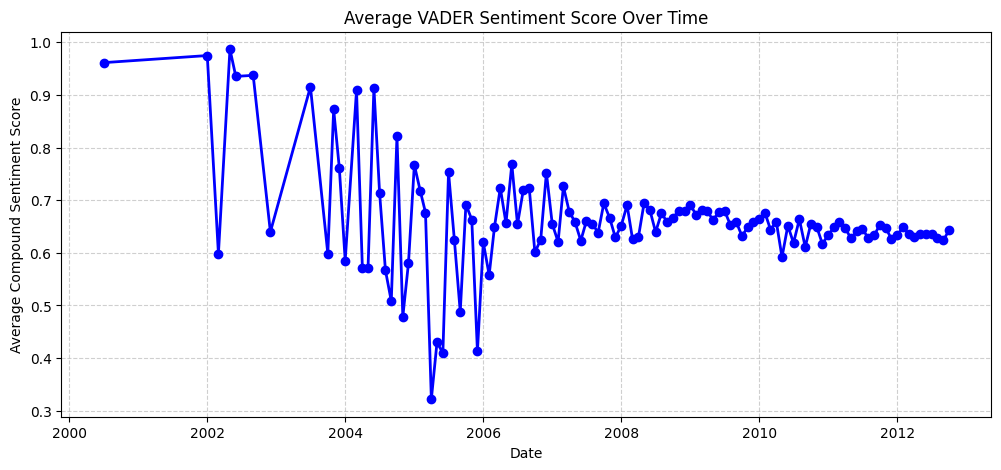

In [15]:
# Compute VADER polarity scores (compound score) for each review
df['VADER_Compound'] = df['Text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Group by YearMonth to compute average compound sentiment score
monthly_sentiment = df.groupby('YearMonth')['VADER_Compound'].mean().reset_index()
monthly_sentiment['YearMonth'] = monthly_sentiment['YearMonth'].dt.to_timestamp()

# Plot sentiment trend over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_sentiment['YearMonth'], monthly_sentiment['VADER_Compound'], marker='o', color='b', linewidth=2)
plt.title('Average VADER Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('graphs/sentiment_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### VADER Sentiment Trend Analysis Over Time

- **Early Volatility:** Significant fluctuations in compound sentiment scores prior to 2006 are driven by low sample sizes in early review data.
- **Long-Term Trend:** As review volume expands over time, the average monthly VADER compound score stabilizes in the **0.65 – 0.70** range, reflecting sustained positive consumer perception across the platform.

# Step 6: Side-by-Side Accuracy Comparison & Tradeoffs

In [16]:
# Calculate Accuracy for both approaches
vader_acc = accuracy_score(df['Sentiment'], df['VADER_Sentiment'])
ml_acc = accuracy_score(y_test, y_pred)

print(f"VADER Model Accuracy: {vader_acc * 100:.2f}%")
print(f"ML Model Accuracy (Logistic Regression): {ml_acc * 100:.2f}%")

VADER Model Accuracy: 79.47%
ML Model Accuracy (Logistic Regression): 77.68%


### Summary of Model Comparison & Tradeoffs

| Feature / Metric | Lexicon Baseline (VADER) | Supervised ML (TF-IDF + LogReg) |
| :--- | :--- | :--- |
| **Accuracy** | ~79.5% | ~77.9% |
| **Negative F1-Score** | **0.46** (Poor Recall: 40%) | **0.64** (Better Recall: 70%) |
| **Neutral F1-Score** | **0.06** (Fails to detect) | **0.32** (Substantial improvement) |
| **Training Required** | None (Pre-trained lexicon) | Requires labeled training data |
| **Key Advantage** | Fast execution, domain-agnostic | Captures domain-specific vocabulary and handles minority classes better |

### Step 7:  Model Inference & Custom Case Testing

To evaluate the trained **Logistic Regression** model in a production-like environment, we test its performance on custom, unseen review strings representing distinct sentiment edge cases:
- **Positive Sentiment:** Clear high-satisfaction feedback with high-frequency positive n-grams.
- **Negative Sentiment:** Explicit complaints involving logistics, delivery delays, and damaged goods.
- **Neutral / Mixed Sentiment:** Subtle, moderate feedback ("just average") to verify if class probabilities accurately reflect mild disappointment rather than binary positive/negative classification.

Extracting predicted class probabilities (`predict_proba`) allows down-stream systems to establish confidence thresholds before auto-flagging reviews for human support review.

In [17]:
# Function to test custom review text on the trained Logistic Regression model
def predict_review_sentiment(review_text):
    vec_text = tfidf.transform([review_text])
    prediction = lr_model.predict(vec_text)[0]
    probabilities = lr_model.predict_proba(vec_text)[0]
    
    print(f"Review: \"{review_text}\"")
    print(f"Predicted Sentiment: {prediction}")
    print(f"Class Probabilities: Positive: {probabilities[2]:.2f}, Neutral: {probabilities[1]:.2f}, Negative: {probabilities[0]:.2f}\n")

# Test custom cases
predict_review_sentiment("The dog food was fresh and high quality. My pet loved it!")
predict_review_sentiment("It took three weeks to arrive and the box was completely damaged.")
predict_review_sentiment("The packaging was fine, but the taste was just average.")

Review: "The dog food was fresh and high quality. My pet loved it!"
Predicted Sentiment: Positive
Class Probabilities: Positive: 0.92, Neutral: 0.05, Negative: 0.02

Review: "It took three weeks to arrive and the box was completely damaged."
Predicted Sentiment: Negative
Class Probabilities: Positive: 0.08, Neutral: 0.15, Negative: 0.77

Review: "The packaging was fine, but the taste was just average."
Predicted Sentiment: Neutral
Class Probabilities: Positive: 0.01, Neutral: 0.96, Negative: 0.03



## Step 8: Business Recommendations & Key Takeaways

### Key Takeaways
1. **Model Selection for E-Commerce:** While VADER achieved slightly higher overall accuracy due to class imbalance, **TF-IDF + Logistic Regression is significantly better for real-world application** because it catches **70% of negative reviews** (compared to VADER's 40%).
2. **Class Imbalance Handling:** Using `class_weight='balanced'` in Logistic Regression proved essential for capturing critical low-star feedback.

### Business Recommendations
- **Auto-Flagging Escalations:** Integrate the Logistic Regression model into customer service pipelines to auto-route predicted **Negative** reviews to support teams within 1 hour.
- **Product Monitoring:** Product managers can track the monthly VADER compound score trend to quickly identify quality regressions following formula or packaging changes.